In [1]:
from gr00t.data.dataset import LeRobotSingleDataset
from gr00t.data.schema import EmbodimentTag
from gr00t.experiment.data_config import load_data_config

# export PYTHONWARNINGS="ignore"
import os
os.environ["PYTHONWARNINGS"] = "ignore"

/home/shrelic/miniforge3/envs/gr00t/lib/python3.10/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
2025-10-17 11:24:24.071766: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-17 11:24:24.094232: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-17 11:24:24.094251: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register fac

In [2]:
DATA_CONFIG_CLS = "examples.UAV_Flow.custom_data_config:UAVFlowFirstLastFrameStateDataConfig"
# DATASET_PATH = "/home/shrelic/projects/UAV-Flow-Gr00t/UAVFlowSimLeRobot-eval"
DATASET_PATH = "/home/shrelic/projects/UAV-Flow-Gr00t/UAVFlowSimLeRobot-train"

data_config_cls = load_data_config(DATA_CONFIG_CLS)
modality_configs = data_config_cls.modality_config()

Loading external config: examples.UAV_Flow.custom_data_config.UAVFlowFirstLastFrameStateDataConfig


In [3]:
dataset = LeRobotSingleDataset(
    dataset_path=DATASET_PATH,
    modality_configs=modality_configs,
    embodiment_tag=EmbodimentTag.NEW_EMBODIMENT,
    video_backend="torchvision_av",
)

Initialized dataset UAVFlowSimLeRobot-train with EmbodimentTag.NEW_EMBODIMENT


In [8]:
dataset[1]["state.drone"], dataset[1]["annotation.human.action.task_description"], dataset[0]["video.ego_view"].shape

/home/shrelic/miniforge3/envs/gr00t/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
/home/shrelic/miniforge3/envs/gr00t/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
/home/shrelic/miniforge3/envs/gr00t/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The vi

(array([[ 1.00001001e+01, -3.35286086e-06,  0.00000000e+00,
          0.00000000e+00]]),
 ['Navigate to a point 5.5 meters away from the dog'],
 (2, 256, 256, 3))

/home/shrelic/miniforge3/envs/gr00t/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
/home/shrelic/miniforge3/envs/gr00t/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
/home/shrelic/miniforge3/envs/gr00t/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The vi

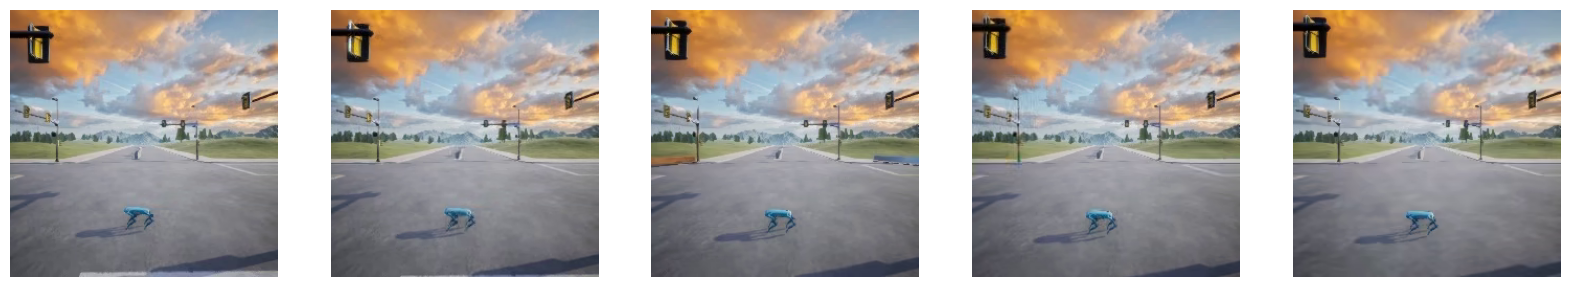

In [6]:
# use matplotlib to visualize the images
import matplotlib.pyplot as plt
import numpy as np

images = []
for i in range(5):
    image = dataset[i]["video.ego_view"][1]
    # image is in HWC format, convert it to CHW format
    image = image.transpose(2, 0, 1)
    images.append(image)   

fig, axs = plt.subplots(1, 5, figsize=(20, 5))
for i, image in enumerate(images):
    axs[i].imshow(np.transpose(image, (1, 2, 0)))
    axs[i].axis("off")
plt.show()

/home/shrelic/miniforge3/envs/gr00t/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
/home/shrelic/miniforge3/envs/gr00t/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
/home/shrelic/miniforge3/envs/gr00t/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The vi

[[0.0, 0.0, 0.0], [10.000100135803223, -3.352860858285567e-06, 0.0], [20.000200271606445, 8.546209755877499e-06, 0.0], [29.99981117248535, -9.444496754440479e-06, 0.0], [32.08180236816406, -3.344710648889304e-06, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]]


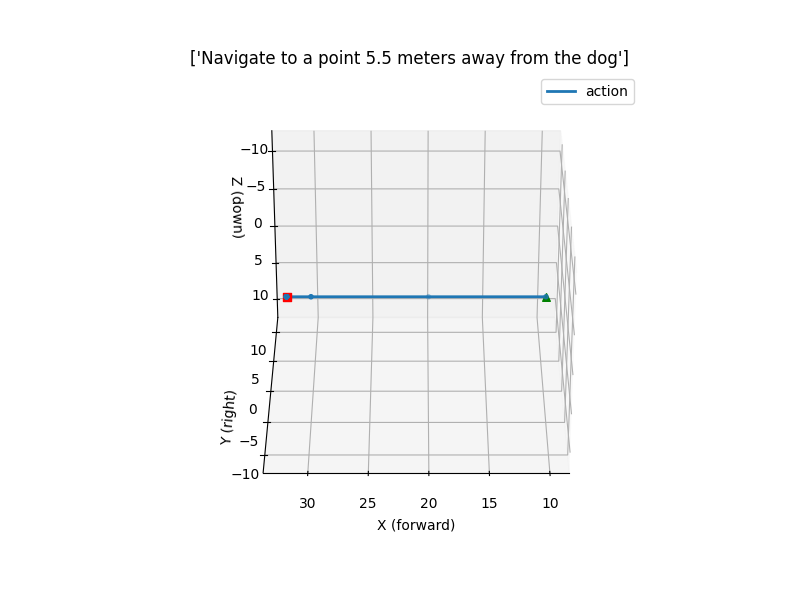

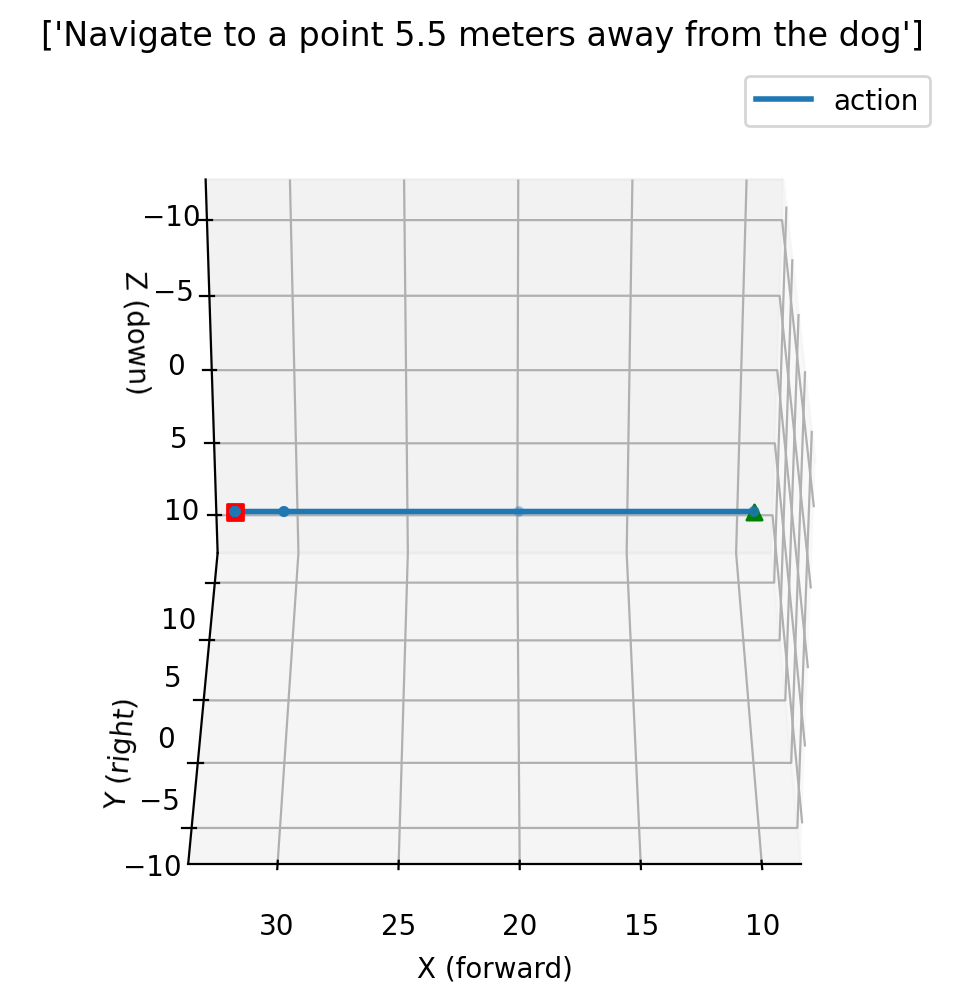

In [13]:
%matplotlib widget
from utils.rotation import body_to_world_pose
action = dataset[0]["action.delta_pose"]
task = dataset[0]["annotation.human.action.task_description"]

points = []
state_points = []
curr_point = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])  # x,y,z,yaw,pitch,roll
last_point = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])  # x,y,z,yaw,pitch,roll
for i, pose in enumerate(action):
    # print(f"Step {i}: {pose}")
    curr_point = np.array([pose[0], pose[1], pose[2], 0.0, 0.0, pose[3]])  # x,y,z,roll,pitch,yaw
    world_pose = body_to_world_pose(last_point, curr_point)
    points.append([world_pose[0].item(), world_pose[1].item(), world_pose[2].item()])
    state_points.append(dataset[i]["state.drone"][0][:3].tolist())
    last_point = world_pose
        
# for i, p in enumerate(points):
#     print(f"Point {i}: {p}")
print(state_points)
from utils.draw import plot_3d_trajectory
plot_3d_trajectory({"action": points}, title=task, show=True)

In [14]:
import json_numpy
import numpy as np
import requests
from pathlib import Path

json_numpy.patch()

def get_action_from_server(data, ip = "10.29.230.87", port=5555):
    keys = ["video.ego_view", "state.drone", "annotation.human.action.task_description"]
    obs = {key: data[key] for key in keys}
    response = requests.post(
        f"http://{ip}:{port}/act",
        json={"observation": obs},
    )
    action = response.json()
    return action

In [9]:
dataset[0]["annotation.human.action.task_description"]

/home/shrelic/miniforge3/envs/gr00t/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


['Navigate to a point 5.5 meters away from the dog']

/home/shrelic/miniforge3/envs/gr00t/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
/home/shrelic/miniforge3/envs/gr00t/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
/home/shrelic/miniforge3/envs/gr00t/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The vi

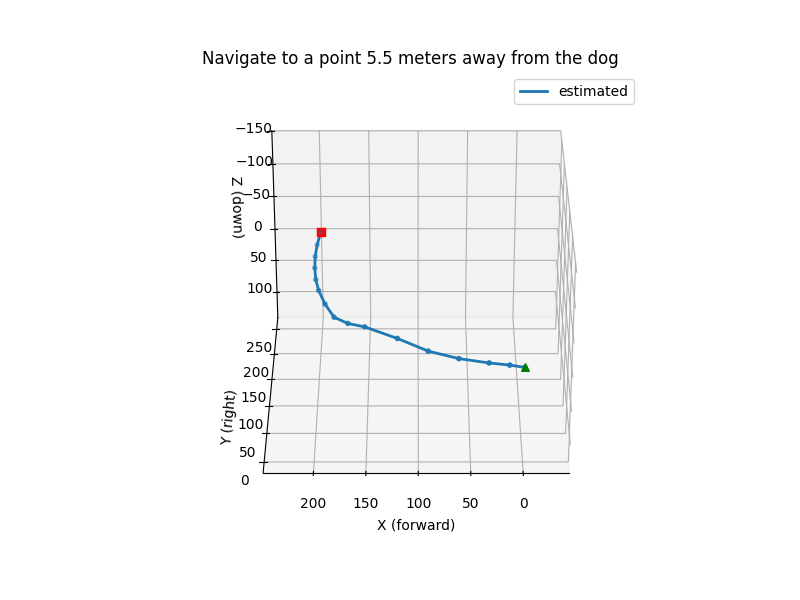

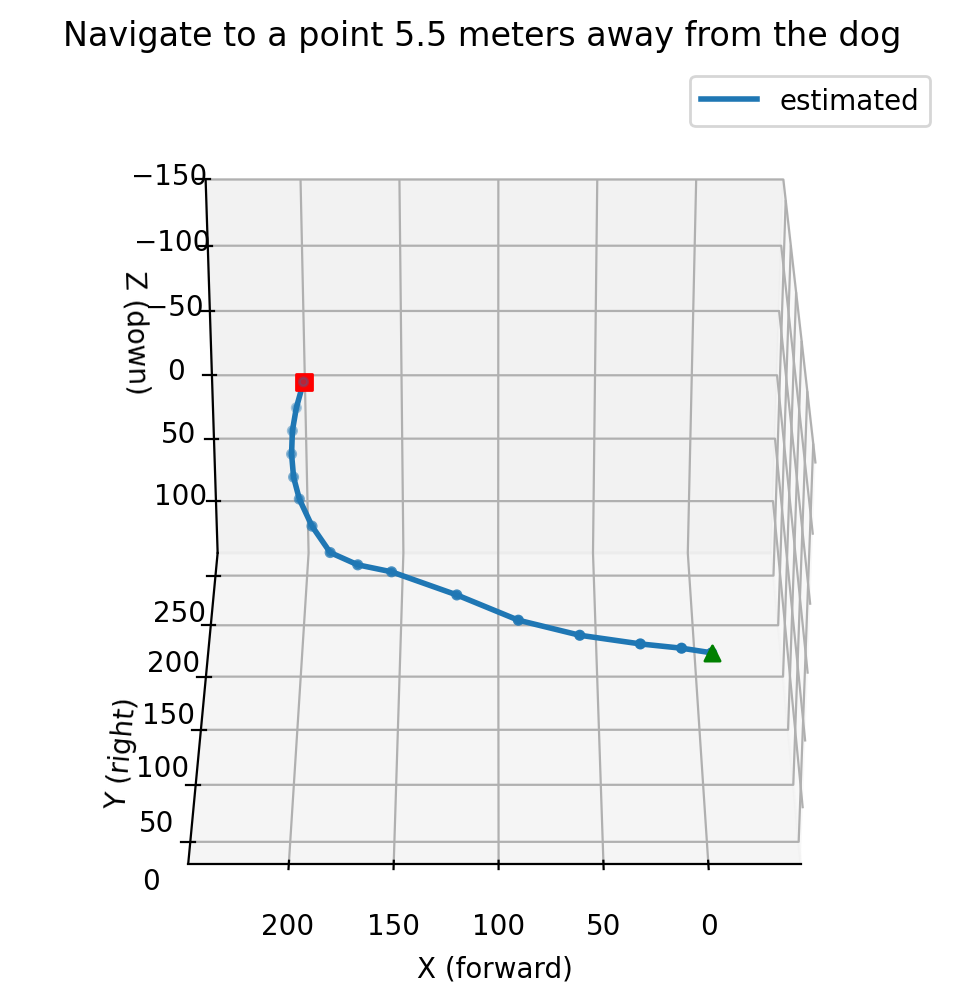

In [20]:
ACTION_KEY = "action.delta_pose"
horizon = 2
num_points_to_draw = 16
poses = []

start_state = np.array([0.0, 0.0, 0.0, 0.0]) # trick, all states are starting point
curr_point = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])  # x,y,z,roll,pitch,yaw
n_points = 0
while n_points < num_points_to_draw:
    data = dataset[n_points]
    data["state.drone"] = body_to_world_pose(curr_point, start_state)[None, :4]
    data["annotation.human.action.task_description"] = ["just keep going straight"]
    action = get_action_from_server(data)
    for step in range(horizon):
        poses.append(curr_point[:3].tolist())
        delta_pose = action[ACTION_KEY][step]
        curr_point = body_to_world_pose(curr_point, np.insert(delta_pose, [3,3], [0.0, 0.0]))  # x,y,z,roll,pitch,yaw
        n_points += 1
        if n_points >= num_points_to_draw:
            break

plot_3d_trajectory({"estimated": poses}, title=dataset[0]["annotation.human.action.task_description"][0], show=True)

Step 0: [ 0.01699519 -0.02379489 -0.00648189  3.0206451 ]
Step 1: [-0.01019692 -0.0650506   0.03788638  0.69659424]
Step 2: [-0.04335546  0.02968788  0.07948303 -3.364441  ]
Step 3: [-0.067626    0.02941561 -0.02031469  0.6573639 ]
Step 4: [-0.08685327  0.04614186  0.09463     3.195053  ]
Step 5: [ 0.00888133  0.1263566   0.04239726 -2.4813232 ]
Step 6: [-0.01136327  0.04017401  0.02792645  2.4359741 ]
Step 7: [-0.00373173 -0.03127217  0.01712537 -1.0926056 ]
Step 8: [-0.04059887  0.02522945 -0.04240179  3.171112  ]
Step 9: [-0.08270073  0.00218987  0.01082587 -0.13801575]
Step 10: [ 0.03800154 -0.06759167  0.04140162 -0.99072266]
Step 11: [ 0.0498383  -0.02130413  0.02292919 -1.3734894 ]
Step 12: [ 0.01991868  0.00608301 -0.00275779 -0.09751892]
Step 13: [ 0.02345943 -0.02449584 -0.10213423  2.48526   ]
Step 14: [ 0.03641534 -0.1057229   0.07476926 -2.020584  ]
Step 15: [0.09908009 0.04332256 0.08257699 1.96492   ]
Point 0: [0.01699519157409668, -0.023794889450073242, -0.0064818859100

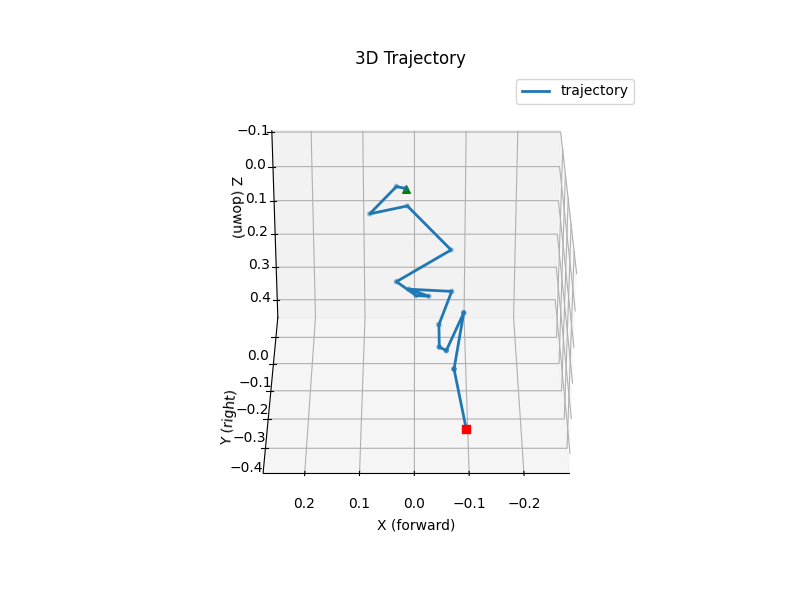

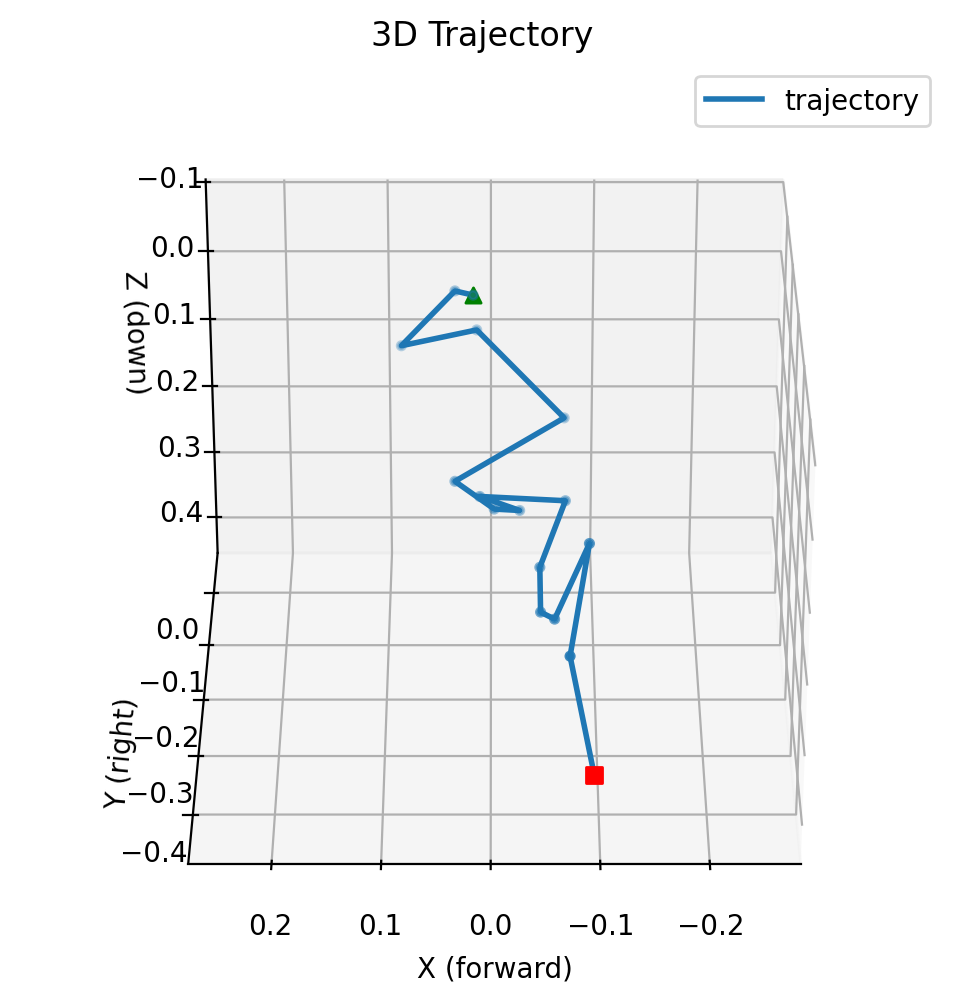

In [ ]:
points = []
curr_point = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])  # x,y,z,yaw,pitch,roll
last_point = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])  # x,y,z,yaw,pitch,roll
for i, pose in enumerate(action[ACTION_KEY]):
    print(f"Step {i}: {pose}")
    curr_point = np.array([pose[0], pose[1], pose[2], 0.0, 0.0, pose[3]])  # x,y,z,roll,pitch,yaw
    world_pose = body_to_world_pose(last_point, curr_point)
    points.append([world_pose[0].item(), world_pose[1].item(), world_pose[2].item()])
    last_point = world_pose
    
for i, p in enumerate(points):
    print(f"Point {i}: {p}")
from utils.draw import plot_3d_trajectory
plot_3d_trajectory(points, save_path="out.png", title="3D Trajectory", show=True)

In [ ]:
from io import BytesIO
from PIL import Image
import base64
from typing import List
import requests

class OpenVLAClient:
    """Convenience client for the OpenVLA action server.

    Example:
        client = OpenVLAClient('http://127.0.0.1:5007')
        resp = client.predict_from_image_path('debug.jpg', 'fly to the red building', [0,0,1,0])
    """

    def __init__(self, server_url: str = "http://127.0.0.1:5007", timeout: int = 20):
        self.server_url = server_url.rstrip("/")
        self.timeout = timeout

    def _encode_pil_to_base64(self, img: Image.Image, fmt: str = "JPEG") -> str:
        buf = BytesIO()
        img.convert("RGB").save(buf, format=fmt)
        return base64.b64encode(buf.getvalue()).decode("utf-8")

    def _array_to_pil(self, arr: np.ndarray) -> Image.Image:
        """Convert a numpy array to a PIL Image.

        Accepts:
          - uint8 arrays with shape (H, W, 3) or (H, W)
          - float arrays in range [0,1] or [0,255]

        The function will convert to RGB. Input is expected to be in RGB order.
        """
        if not isinstance(arr, np.ndarray):
            raise TypeError("arr must be a numpy.ndarray")

        # If float, scale to 0-255
        if np.issubdtype(arr.dtype, np.floating):
            arr_proc = arr.copy()
            # assume in [0,1] if max <= 1.0
            if arr_proc.max() <= 1.0:
                arr_proc = (arr_proc * 255.0).astype(np.uint8)
            else:
                arr_proc = arr_proc.astype(np.uint8)
        else:
            arr_proc = arr.astype(np.uint8)

        # Grayscale
        if arr_proc.ndim == 2:
            return Image.fromarray(arr_proc, mode="L").convert("RGB")

        # Color HxWx3
        if arr_proc.ndim == 3 and arr_proc.shape[2] == 3:
            return Image.fromarray(arr_proc, mode=None).convert("RGB")

        raise ValueError(f"Unsupported array shape/dtype for image: {arr_proc.shape}, {arr_proc.dtype}")


    def predict(self, image_b64: str, instr: str, proprio: List[float]) -> dict:
        url = self.server_url + "/predict"
        payload = {"image": image_b64, "instr": instr, "proprio": proprio}
        resp = requests.post(url, json=payload, timeout=self.timeout)
        resp.raise_for_status()
        return resp.json()


    def predict_from_pil(self, img: Image.Image, instr: str, proprio: List[float]) -> dict:
        image_b64 = self._encode_pil_to_base64(img)
        return self.predict(image_b64, instr, proprio)

    def predict_from_array(self, arr: np.ndarray, instr: str, proprio: List[float]) -> dict:
        """Accept a numpy array (H,W,3) or (H,W) and send prediction request.

        The input array is expected to be in RGB order. If you have a BGR array
        (e.g., from OpenCV), convert it first via arr[..., ::-1].
        """
        img = self._array_to_pil(arr)
        return self.predict_from_pil(img, instr, proprio)

In [ ]:
dataset[0]["video.ego_view"].shape

In [ ]:
client = OpenVLAClient('http://127.0.0.1:5007')
num_steps = 16

poses = []
proprio = [0.0, 0.0, 0.0, 0.0]  # x,y,z,yaw
for step in range(num_steps):
    poses.append(proprio)
    frame = dataset[step]["video.ego_view"][1]
    instr = dataset[step]["annotation.human.action.task_description"][0]
    resp = client.predict_from_array(frame, instr, proprio)
    proprio = resp["action"][0]
    

# draw first 4 frames
n = 4
fig, axs = plt.subplots(1, n, figsize=(15, 5))
for i in range(n):
    axs[i].imshow(dataset[i]["video.ego_view"][1])
    axs[i].axis("off")
plt.show()

In [ ]:
points = [pose[:3] for pose in poses]
for i, p in enumerate(points):
    print(f"Point {i}: {p}")
plot_3d_trajectory(points, title=dataset[0]["annotation.human.action.task_description"], show=True)